# Test Amplitude Compensation for Universal GASP

This notebook validates the T2/T1 estimation and amplitude compensation approach.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')

from gasp.ssfp import ssfp
from gasp.gasp import train_gasp, run_gasp
from gasp import responses
from gasp.simulation import SSFPParams, simulate_ssfp_simple
from gasp.compensated import (
    estimate_t2_from_tr_decay,
    estimate_t1_from_profile,
    estimate_t1_t2_planet,
    normalize_signals,
    train_compensated_gasp,
    run_compensated_gasp,
)

# Acquisition parameters (matching gasp_analysis.ipynb)
TRs = [5e-3, 10e-3, 15e-3]
alpha = np.deg2rad(60)  # 60 degrees as in analysis notebook
npcs = 8  # Match analysis notebook
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

# Image dimensions
WIDTH = 256   # Spectral dimension (frequency samples)
HEIGHT = 1    # Spatial dimension

# Build SSFPParams for simulation (matches gasp_analysis.ipynb pattern)
n_acq = npcs * len(TRs)
alpha_list = [alpha] * n_acq
TR_list = []
pc_list = []
for tr in TRs:
    for pc in pcs:
        TR_list.append(tr)
        pc_list.append(pc)

PARAMS = SSFPParams(n_acq, alpha_list, TR_list, pc_list)
MIN_TR = TRs[0]

def simulate_tissue(T1, T2, width=WIDTH, height=HEIGHT):
    """Simulate bSSFP for a tissue type using SSFPParams (matching analysis notebook)."""
    M = simulate_ssfp_simple(
        width=width, height=height,
        T1=T1, T2=T2,
        params=PARAMS,
        minTR=MIN_TR
    )
    return M

def simulate_multi_tr(T1, T2, TRs, alpha, pcs, M0=1.0):
    """Simulate multi-TR phase-cycled bSSFP signal for a single voxel (on-resonance)."""
    signals = []
    for TR in TRs:
        TE = TR / 2
        sig = ssfp(T1, T2, TR, TE, alpha, dphi=pcs, M0=M0)
        signals.append(sig)
    return np.concatenate(signals, axis=-1)

def simulate_single_tr(T1, T2, TR, alpha, pcs, M0=1.0):
    """Simulate phase-cycled bSSFP for single TR (for PLANET)."""
    TE = TR / 2
    return ssfp(T1, T2, TR, TE, alpha, dphi=pcs, M0=M0)

print(f"Simulation parameters:")
print(f"  TRs: {[tr*1000 for tr in TRs]} ms")
print(f"  Flip angle: {np.rad2deg(alpha):.0f} degrees")
print(f"  Phase cycles: {npcs}")
print(f"  Total acquisitions: {n_acq}")

Simulation parameters:
  TRs: [5.0, 10.0, 15.0] ms
  Flip angle: 60 degrees
  Phase cycles: 8
  Total acquisitions: 24


## Test T1/T2 Estimation using PLANET

PLANET (Phase-cycLed bSSFP ANalytical T2/T1 Estimation) exploits the elliptical property of phase-cycled bSSFP signals:

- In the complex plane, signals at different phase cycles trace an ellipse
- The ellipse geometry (axes, center, orientation) encodes T1, T2, and off-resonance
- This provides simultaneous T1/T2 estimation from a single TR acquisition

Test 1: Varying T2, Fixed T1=1000ms
--------------------------------------------------
True T2 (ms)    Est T2 (ms)     Est T1 (ms)    
20.0            20.00           1000.00        
50.0            50.00           1000.00        
80.0            80.00           1000.00        
100.0           100.00          1000.00        
150.0           150.00          1000.00        
200.0           200.00          1000.00        



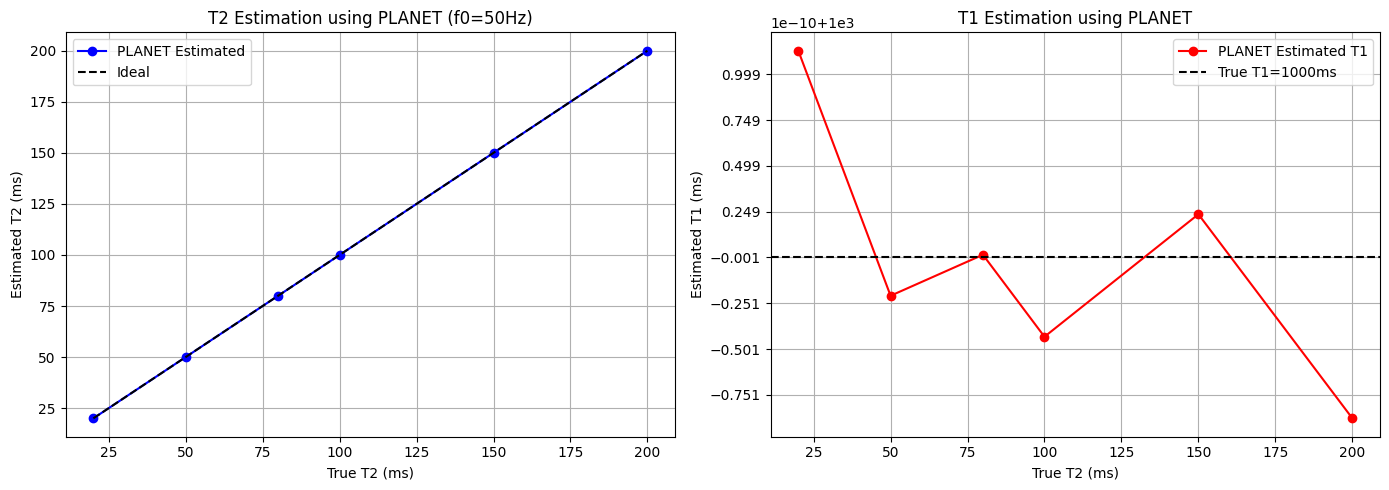

T2 Mean absolute error: 0.00 ms
T1 Mean absolute error: 0.00 ms


In [32]:
# Test T1/T2 estimation using PLANET algorithm
# PLANET requires OFF-RESONANCE signals to form ellipses in the complex plane

true_t2_values = np.array([0.02, 0.05, 0.08, 0.1, 0.15, 0.2])
T1_fixed = 1.0  # Fixed T1
TR = TRs[0]  # Use first TR for PLANET
f0 = 50  # Off-resonance frequency in Hz (REQUIRED for PLANET!)

estimated_t1_planet = []
estimated_t2_planet = []

for t2 in true_t2_values:
    # Simulate with OFF-RESONANCE (f0 != 0) - this creates the ellipse
    TE = TR / 2
    signals = ssfp(T1_fixed, t2, TR, TE, alpha, dphi=pcs, field_map=f0)
    
    # PLANET estimation
    t1_est, t2_est, f0_est = estimate_t1_t2_planet(
        signals[np.newaxis, :], TR, alpha, npcs
    )
    # Extract scalar values
    estimated_t1_planet.append(float(np.atleast_1d(t1_est)[0]))
    estimated_t2_planet.append(float(np.atleast_1d(t2_est)[0]))

estimated_t1_planet = np.array(estimated_t1_planet)
estimated_t2_planet = np.array(estimated_t2_planet)

# Print actual values for debugging
print("Test 1: Varying T2, Fixed T1=1000ms")
print("-" * 50)
print(f"{'True T2 (ms)':<15} {'Est T2 (ms)':<15} {'Est T1 (ms)':<15}")
for i, t2 in enumerate(true_t2_values):
    print(f"{t2*1000:<15.1f} {estimated_t2_planet[i]*1000:<15.2f} {estimated_t1_planet[i]*1000:<15.2f}")
print()

# Plot T2 estimation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_t2_values * 1000, estimated_t2_planet * 1000, 'bo-', label='PLANET Estimated')
axes[0].plot(true_t2_values * 1000, true_t2_values * 1000, 'k--', label='Ideal')
axes[0].set_xlabel('True T2 (ms)')
axes[0].set_ylabel('Estimated T2 (ms)')
axes[0].set_title(f'T2 Estimation using PLANET (f0={f0}Hz)')
axes[0].legend()
axes[0].grid(True)

# Plot T1 estimation  
axes[1].plot(true_t2_values * 1000, estimated_t1_planet * 1000, 'ro-', label='PLANET Estimated T1')
axes[1].axhline(T1_fixed * 1000, color='k', linestyle='--', label=f'True T1={T1_fixed*1000:.0f}ms')
axes[1].set_xlabel('True T2 (ms)')
axes[1].set_ylabel('Estimated T1 (ms)')
axes[1].set_title('T1 Estimation using PLANET')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"T2 Mean absolute error: {np.mean(np.abs(estimated_t2_planet - true_t2_values)) * 1000:.2f} ms")
print(f"T1 Mean absolute error: {np.mean(np.abs(estimated_t1_planet - T1_fixed)) * 1000:.2f} ms")

## Test T1 Estimation with PLANET (varying T1)

Test 2: Varying T1, Fixed T2=100ms
--------------------------------------------------
True T1 (ms)    Est T1 (ms)     Est T2 (ms)    
300.0           300.00          100.00         
500.0           500.00          100.00         
800.0           800.00          100.00         
1000.0          1000.00         100.00         
1500.0          1500.00         100.00         
2000.0          2000.00         100.00         



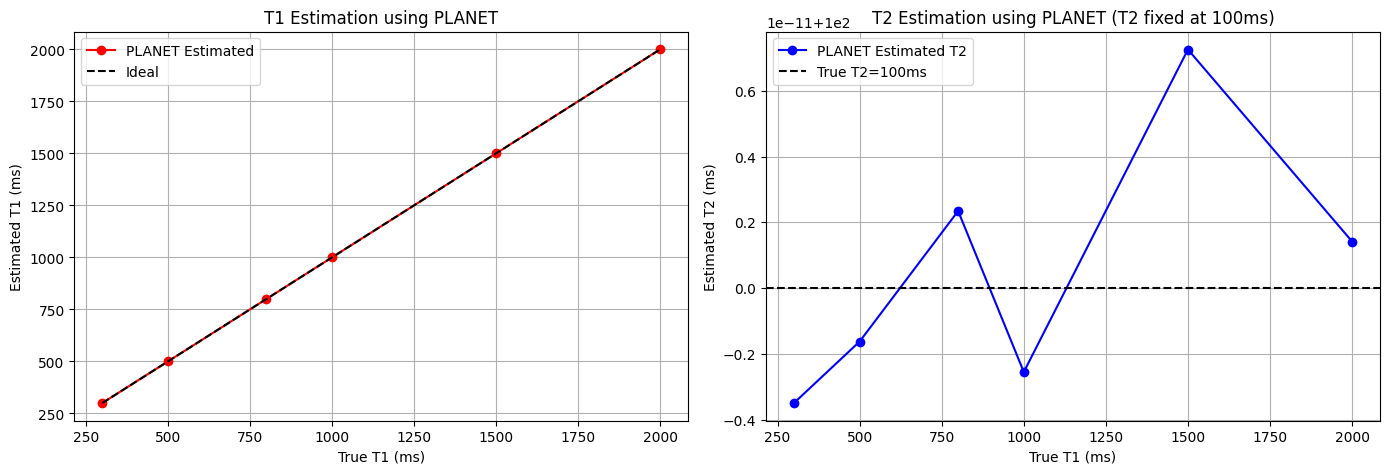

T1 Mean absolute error: 0.00 ms
T2 Mean absolute error: 0.00 ms


In [33]:
# Test PLANET T1 estimation with varying T1 values
true_t1_values = np.array([0.3, 0.5, 0.8, 1.0, 1.5, 2.0])
T2_fixed = 0.1  # Fixed T2
TR = TRs[0]
f0 = 50  # Off-resonance in Hz

estimated_t1 = []
estimated_t2_check = []

for t1 in true_t1_values:
    # Simulate with off-resonance
    TE = TR / 2
    signals = ssfp(t1, T2_fixed, TR, TE, alpha, dphi=pcs, field_map=f0)
    
    t1_est, t2_est, f0_est = estimate_t1_t2_planet(
        signals[np.newaxis, :], TR, alpha, npcs
    )
    # Extract scalar values
    estimated_t1.append(float(np.atleast_1d(t1_est)[0]))
    estimated_t2_check.append(float(np.atleast_1d(t2_est)[0]))

estimated_t1 = np.array(estimated_t1)
estimated_t2_check = np.array(estimated_t2_check)

# Print actual values for debugging
print("Test 2: Varying T1, Fixed T2=100ms")
print("-" * 50)
print(f"{'True T1 (ms)':<15} {'Est T1 (ms)':<15} {'Est T2 (ms)':<15}")
for i, t1 in enumerate(true_t1_values):
    print(f"{t1*1000:<15.1f} {estimated_t1[i]*1000:<15.2f} {estimated_t2_check[i]*1000:<15.2f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_t1_values * 1000, estimated_t1 * 1000, 'ro-', label='PLANET Estimated')
axes[0].plot(true_t1_values * 1000, true_t1_values * 1000, 'k--', label='Ideal')
axes[0].set_xlabel('True T1 (ms)')
axes[0].set_ylabel('Estimated T1 (ms)')
axes[0].set_title('T1 Estimation using PLANET')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(true_t1_values * 1000, estimated_t2_check * 1000, 'bo-', label='PLANET Estimated T2')
axes[1].axhline(T2_fixed * 1000, color='k', linestyle='--', label=f'True T2={T2_fixed*1000:.0f}ms')
axes[1].set_xlabel('True T1 (ms)')
axes[1].set_ylabel('Estimated T2 (ms)')
axes[1].set_title('T2 Estimation using PLANET (T2 fixed at 100ms)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"T1 Mean absolute error: {np.mean(np.abs(estimated_t1 - true_t1_values)) * 1000:.2f} ms")
print(f"T2 Mean absolute error: {np.mean(np.abs(estimated_t2_check - T2_fixed)) * 1000:.2f} ms")

## Compare Standard vs Compensated GASP

In [34]:
# Create spectral target profile (Gaussian passband)
#D = responses.gaussian(WIDTH, bw=0.2, shift=0)
D = responses.bandpass(WIDTH, bw=0.2, shift=0)

# Training tissue: Gray Matter (T2/T1 = 0.111, matching analysis notebook)
TRAIN_T1, TRAIN_T2 = 0.9, 0.1
I_train = simulate_tissue(T1=TRAIN_T1, T2=TRAIN_T2)

# Train both methods WITH L2 regularization (matching analysis notebook)
_, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)

# For compensated GASP: use KNOWN T1/T2 values (since we're simulating)
_, coeffs_comp, meta = train_compensated_gasp(
    I_train, D, TRs, alpha, npcs, method='affine',
    known_t1=TRAIN_T1, known_t2=TRAIN_T2,  # Use known values!
    useL2=True, lam=1e-2
)

# Test tissues with different T2/T1 ratios
test_tissues = {
    'Gray Matter (train)': {'T1': 0.9, 'T2': 0.1},    # T2/T1 = 0.111
    'Muscle':              {'T1': 0.9, 'T2': 0.05},   # T2/T1 = 0.055
    'White Matter':        {'T1': 0.6, 'T2': 0.08},   # T2/T1 = 0.133
    'Fat':                 {'T1': 0.25, 'T2': 0.07},  # T2/T1 = 0.28
}

results = []
for name, params in test_tissues.items():
    I_test = simulate_tissue(T1=params['T1'], T2=params['T2'])

    out_std = run_gasp(I_test, coeffs_std, method='affine')
    # Use KNOWN T1/T2 for the test tissue
    out_comp = run_compensated_gasp(
        I_test, coeffs_comp, meta, method='affine',
        known_t1=params['T1'], known_t2=params['T2']
    )

    # Compute RMSE relative to target profile
    rmse_std = np.sqrt(np.mean((np.abs(out_std).flatten() - D) ** 2))
    rmse_comp = np.sqrt(np.mean((np.abs(out_comp).flatten() - D) ** 2))

    results.append({
        'tissue': name,
        'T1': params['T1'],
        'T2': params['T2'],
        'T2/T1': params['T2'] / params['T1'],
        'RMSE_standard': rmse_std,
        'RMSE_compensated': rmse_comp,
        'improvement_%': (rmse_std - rmse_comp) / rmse_std * 100
    })

# Display results
print('=' * 75)
print('AMPLITUDE COMPENSATION RESULTS')
print('=' * 75)
print(f'Training tissue: T1={TRAIN_T1*1000:.0f}ms, T2={TRAIN_T2*1000:.0f}ms, T2/T1={TRAIN_T2/TRAIN_T1:.3f}')
print()
print(f"{'Tissue':<24} {'T2/T1':<8} {'Std RMSE':<12} {'Comp RMSE':<12} {'Improvement':<12}")
print('-' * 75)

for r in results:
    print(f"{r['tissue']:<24} {r['T2/T1']:<8.3f} {r['RMSE_standard']:<12.4f} {r['RMSE_compensated']:<12.4f} {r['improvement_%']:>+8.1f}%")

print('=' * 75)
print('Amplitude compensation normalizes signals across tissue types!')

AMPLITUDE COMPENSATION RESULTS
Training tissue: T1=900ms, T2=100ms, T2/T1=0.111

Tissue                   T2/T1    Std RMSE     Comp RMSE    Improvement 
---------------------------------------------------------------------------
Gray Matter (train)      0.111    0.0589       0.0590           -0.3%
Muscle                   0.056    0.1827       0.0711          +61.1%
White Matter             0.133    0.0808       0.0586          +27.6%
Fat                      0.280    0.3771       0.0694          +81.6%
Amplitude compensation normalizes signals across tissue types!


## Visualize Outputs

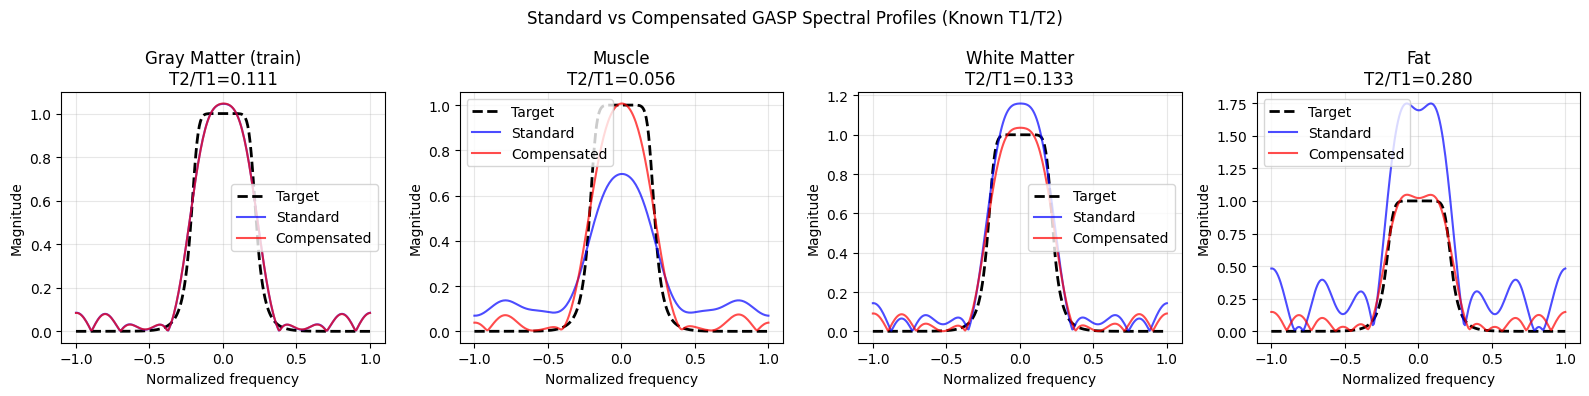

In [35]:
# Visualize spectral profiles
x = np.linspace(-1, 1, WIDTH)

fig, axes = plt.subplots(1, len(test_tissues), figsize=(16, 4))

for i, (name, params) in enumerate(test_tissues.items()):
    I_test = simulate_tissue(T1=params['T1'], T2=params['T2'])

    out_std = np.abs(run_gasp(I_test, coeffs_std, method='affine')).flatten()
    out_comp = np.abs(run_compensated_gasp(
        I_test, coeffs_comp, meta, method='affine',
        known_t1=params['T1'], known_t2=params['T2']
    )).flatten()

    axes[i].plot(x, D, 'k--', label='Target', linewidth=2)
    axes[i].plot(x, out_std, 'b-', label='Standard', alpha=0.7)
    axes[i].plot(x, out_comp, 'r-', label='Compensated', alpha=0.7)
    axes[i].set_title(f'{name}\nT2/T1={params["T2"]/params["T1"]:.3f}')
    axes[i].set_xlabel('Normalized frequency')
    axes[i].set_ylabel('Magnitude')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Standard vs Compensated GASP Spectral Profiles (Known T1/T2)')
plt.tight_layout()
plt.show()

## Training α vs Evaluation T2/T1 Heatmaps

This analysis shows how the training flip angle affects GASP performance across different tissue types (T2/T1 ratios), comparing standard GASP vs amplitude-compensated GASP.

In [36]:
# Sensitivity analysis: Training α vs Evaluation T2/T1

# Define parameter grids
ALPHA_VALUES = np.arange(10, 90, 10)  # 10, 20, ..., 80 degrees
EVAL_T2_T1_RATIOS = np.array([0.05, 0.08, 0.1, 0.12, 0.15, 0.2, 0.25, 0.3])
T1_BASE = 1.0
TRAIN_T2_T1 = 0.1  # Fixed training tissue (Gray Matter-like)

n_alphas = len(ALPHA_VALUES)
n_eval_ratios = len(EVAL_T2_T1_RATIOS)

# MSE matrices: [alpha_idx, eval_ratio_idx]
mse_alpha_std = np.zeros((n_alphas, n_eval_ratios))
mse_alpha_comp = np.zeros((n_alphas, n_eval_ratios))

print("Computing Training α vs Evaluation T2/T1 heatmaps...")
print(f"Training tissue: T2/T1 = {TRAIN_T2_T1}")
print(f"Grid: {n_alphas} alphas x {n_eval_ratios} T2/T1 ratios = {n_alphas * n_eval_ratios} combinations")
print()

# Need to rebuild PARAMS for each alpha
def build_params_for_alpha(alpha_deg):
    """Build SSFPParams for a specific flip angle."""
    alpha_rad = np.deg2rad(alpha_deg)
    n_acq_local = npcs * len(TRs)
    alpha_list = [alpha_rad] * n_acq_local
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs:
            TR_list.append(tr)
            pc_list.append(pc)
    return SSFPParams(n_acq_local, alpha_list, TR_list, pc_list)

def simulate_tissue_alpha(T1, T2, alpha_deg):
    """Simulate tissue with specific flip angle."""
    params = build_params_for_alpha(alpha_deg)
    return simulate_ssfp_simple(
        width=WIDTH, height=HEIGHT,
        T1=T1, T2=T2,
        params=params,
        minTR=TRs[0]
    )

for i, alpha_deg in enumerate(ALPHA_VALUES):
    train_T1 = T1_BASE
    train_T2 = TRAIN_T2_T1 * T1_BASE
    alpha_rad = np.deg2rad(alpha_deg)
    
    # Simulate training data with this alpha
    I_train = simulate_tissue_alpha(T1=train_T1, T2=train_T2, alpha_deg=alpha_deg)
    
    # Train standard GASP
    _, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
    
    # Train compensated GASP
    _, coeffs_comp, meta = train_compensated_gasp(
        I_train, D, TRs, alpha_rad, npcs, method='affine',
        known_t1=train_T1, known_t2=train_T2,
        useL2=True, lam=1e-2
    )
    
    # Evaluate on all test tissues
    for j, eval_ratio in enumerate(EVAL_T2_T1_RATIOS):
        eval_T1 = T1_BASE
        eval_T2 = eval_ratio * T1_BASE
        
        I_test = simulate_tissue_alpha(T1=eval_T1, T2=eval_T2, alpha_deg=alpha_deg)
        
        # Standard GASP
        out_std = run_gasp(I_test, coeffs_std, method='affine')
        mse_std = np.mean((np.abs(out_std).flatten() - D) ** 2)
        mse_alpha_std[i, j] = mse_std
        
        # Compensated GASP
        out_comp = run_compensated_gasp(
            I_test, coeffs_comp, meta, method='affine',
            known_t1=eval_T1, known_t2=eval_T2
        )
        mse_comp = np.mean((np.abs(out_comp).flatten() - D) ** 2)
        mse_alpha_comp[i, j] = mse_comp
    
    print(f"  α={alpha_deg:2d}°: Std MSE={mse_alpha_std[i].mean():.4f}, Comp MSE={mse_alpha_comp[i].mean():.4f}")

print("\nHeatmap computation complete!")
print(f"Standard GASP - Mean MSE: {mse_alpha_std.mean():.6f}")
print(f"Compensated GASP - Mean MSE: {mse_alpha_comp.mean():.6f}")

Computing Training α vs Evaluation T2/T1 heatmaps...
Training tissue: T2/T1 = 0.1
Grid: 8 alphas x 8 T2/T1 ratios = 64 combinations

  α=10°: Std MSE=0.0046, Comp MSE=0.0042
  α=20°: Std MSE=0.0114, Comp MSE=0.0053
  α=30°: Std MSE=0.0208, Comp MSE=0.0045
  α=40°: Std MSE=0.0352, Comp MSE=0.0047
  α=50°: Std MSE=0.0517, Comp MSE=0.0049
  α=60°: Std MSE=0.0676, Comp MSE=0.0047
  α=70°: Std MSE=0.0806, Comp MSE=0.0043
  α=80°: Std MSE=0.0918, Comp MSE=0.0043

Heatmap computation complete!
Standard GASP - Mean MSE: 0.045468
Compensated GASP - Mean MSE: 0.004602


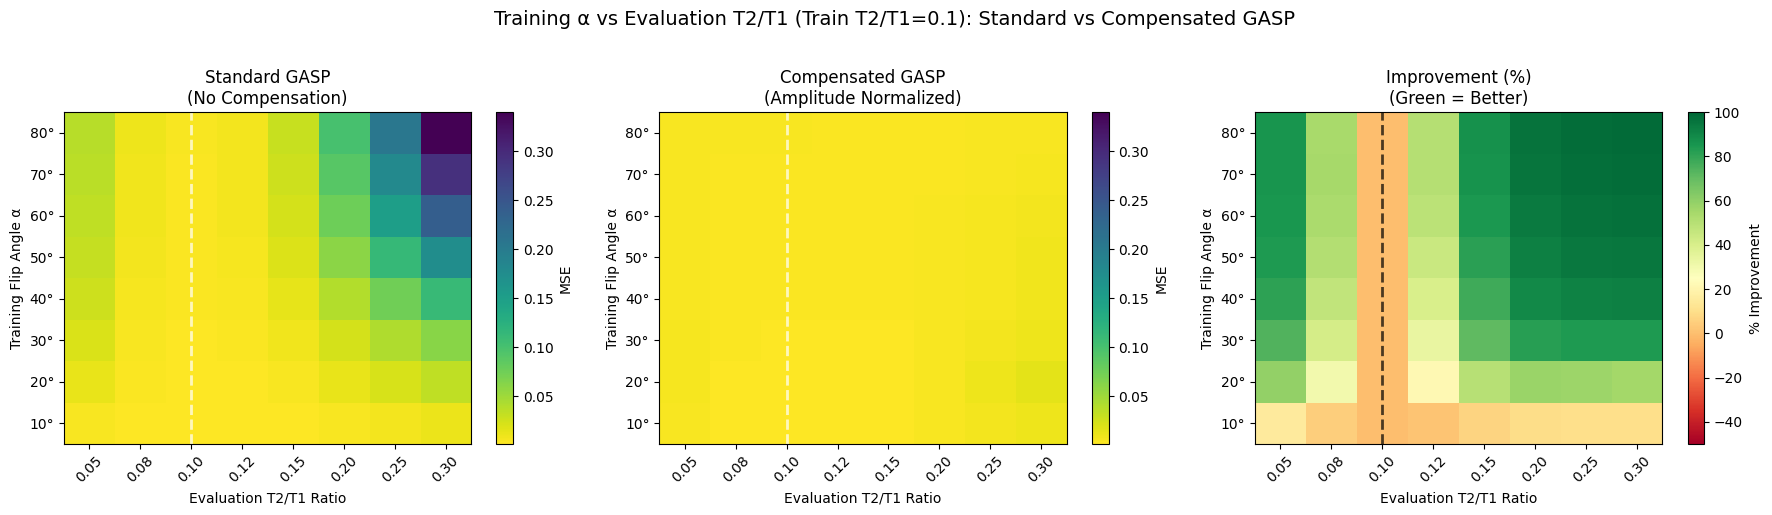


Optimal Flip Angle Analysis:
------------------------------------------------------------
Standard GASP - Best α: 10° (Mean MSE: 0.004626)
Compensated GASP - Best α: 10° (Mean MSE: 0.004178)

Note: White dashed line marks training tissue T2/T1=0.1


In [37]:
# Plot heatmaps: Training α vs Evaluation T2/T1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Unified color scale
vmin_alpha = min(mse_alpha_std.min(), mse_alpha_comp.min())
vmax_alpha = max(mse_alpha_std.max(), mse_alpha_comp.max())

# Standard GASP heatmap
im0 = axes[0].imshow(mse_alpha_std, cmap='viridis_r', aspect='auto',
                      vmin=vmin_alpha, vmax=vmax_alpha, origin='lower')
axes[0].set_xticks(range(n_eval_ratios))
axes[0].set_xticklabels([f'{r:.2f}' for r in EVAL_T2_T1_RATIOS], rotation=45)
axes[0].set_yticks(range(n_alphas))
axes[0].set_yticklabels([f'{a}°' for a in ALPHA_VALUES])
axes[0].set_xlabel('Evaluation T2/T1 Ratio')
axes[0].set_ylabel('Training Flip Angle α')
axes[0].set_title('Standard GASP\n(No Compensation)')
plt.colorbar(im0, ax=axes[0], label='MSE')

# Mark training tissue ratio
train_idx = np.argmin(np.abs(EVAL_T2_T1_RATIOS - TRAIN_T2_T1))
axes[0].axvline(train_idx, color='white', linestyle='--', linewidth=2, alpha=0.7)

# Compensated GASP heatmap
im1 = axes[1].imshow(mse_alpha_comp, cmap='viridis_r', aspect='auto',
                      vmin=vmin_alpha, vmax=vmax_alpha, origin='lower')
axes[1].set_xticks(range(n_eval_ratios))
axes[1].set_xticklabels([f'{r:.2f}' for r in EVAL_T2_T1_RATIOS], rotation=45)
axes[1].set_yticks(range(n_alphas))
axes[1].set_yticklabels([f'{a}°' for a in ALPHA_VALUES])
axes[1].set_xlabel('Evaluation T2/T1 Ratio')
axes[1].set_ylabel('Training Flip Angle α')
axes[1].set_title('Compensated GASP\n(Amplitude Normalized)')
plt.colorbar(im1, ax=axes[1], label='MSE')
axes[1].axvline(train_idx, color='white', linestyle='--', linewidth=2, alpha=0.7)

# Improvement heatmap
improvement_alpha = (mse_alpha_std - mse_alpha_comp) / mse_alpha_std * 100
im2 = axes[2].imshow(improvement_alpha, cmap='RdYlGn', aspect='auto',
                      vmin=-50, vmax=100, origin='lower')
axes[2].set_xticks(range(n_eval_ratios))
axes[2].set_xticklabels([f'{r:.2f}' for r in EVAL_T2_T1_RATIOS], rotation=45)
axes[2].set_yticks(range(n_alphas))
axes[2].set_yticklabels([f'{a}°' for a in ALPHA_VALUES])
axes[2].set_xlabel('Evaluation T2/T1 Ratio')
axes[2].set_ylabel('Training Flip Angle α')
axes[2].set_title('Improvement (%)\n(Green = Better)')
plt.colorbar(im2, ax=axes[2], label='% Improvement')
axes[2].axvline(train_idx, color='black', linestyle='--', linewidth=2, alpha=0.7)

plt.suptitle(f'Training α vs Evaluation T2/T1 (Train T2/T1={TRAIN_T2_T1}): Standard vs Compensated GASP', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print best alpha for each method
print("\nOptimal Flip Angle Analysis:")
print("-" * 60)
mean_mse_per_alpha_std = mse_alpha_std.mean(axis=1)
mean_mse_per_alpha_comp = mse_alpha_comp.mean(axis=1)
best_alpha_std = ALPHA_VALUES[np.argmin(mean_mse_per_alpha_std)]
best_alpha_comp = ALPHA_VALUES[np.argmin(mean_mse_per_alpha_comp)]
print(f"Standard GASP - Best α: {best_alpha_std}° (Mean MSE: {mean_mse_per_alpha_std.min():.6f})")
print(f"Compensated GASP - Best α: {best_alpha_comp}° (Mean MSE: {mean_mse_per_alpha_comp.min():.6f})")
print(f"\nNote: White dashed line marks training tissue T2/T1={TRAIN_T2_T1}")

## Training T2/T1 vs Evaluation T2/T1 Heatmaps

This analysis shows how GASP coefficients trained on one tissue type generalize to other tissues, comparing standard GASP (no compensation) vs amplitude-compensated GASP.

In [38]:
# Sensitivity analysis: Training T2/T1 vs Evaluation T2/T1

# Define tissue grid for analysis
T2_T1_RATIOS = np.array([0.05, 0.08, 0.1, 0.12, 0.15, 0.2, 0.25, 0.3])  # T2/T1 ratios
T1_BASE = 1.0  # Fixed T1 for all tissues

# Reference tissues for annotation
TISSUE_REFS = {
    'Muscle': 0.055,
    'White Matter': 0.133,
    'Gray Matter': 0.111,
    'Fat': 0.28,
}

n_ratios = len(T2_T1_RATIOS)

# MSE matrices: [train_idx, eval_idx]
mse_standard = np.zeros((n_ratios, n_ratios))
mse_compensated = np.zeros((n_ratios, n_ratios))

print("Computing Training T2/T1 vs Evaluation T2/T1 heatmaps...")
print(f"Grid: {n_ratios} x {n_ratios} = {n_ratios**2} combinations")
print()

for i, train_ratio in enumerate(T2_T1_RATIOS):
    train_T1 = T1_BASE
    train_T2 = train_ratio * T1_BASE
    
    # Simulate training data
    I_train = simulate_tissue(T1=train_T1, T2=train_T2)
    
    # Train standard GASP
    _, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
    
    # Train compensated GASP
    _, coeffs_comp, meta = train_compensated_gasp(
        I_train, D, TRs, alpha, npcs, method='affine',
        known_t1=train_T1, known_t2=train_T2,
        useL2=True, lam=1e-2
    )
    
    # Evaluate on all test tissues
    for j, eval_ratio in enumerate(T2_T1_RATIOS):
        eval_T1 = T1_BASE
        eval_T2 = eval_ratio * T1_BASE
        
        I_test = simulate_tissue(T1=eval_T1, T2=eval_T2)
        
        # Standard GASP
        out_std = run_gasp(I_test, coeffs_std, method='affine')
        mse_std = np.mean((np.abs(out_std).flatten() - D) ** 2)
        mse_standard[i, j] = mse_std
        
        # Compensated GASP
        out_comp = run_compensated_gasp(
            I_test, coeffs_comp, meta, method='affine',
            known_t1=eval_T1, known_t2=eval_T2
        )
        mse_comp = np.mean((np.abs(out_comp).flatten() - D) ** 2)
        mse_compensated[i, j] = mse_comp
    
    print(f"  Train T2/T1={train_ratio:.2f}: Std MSE={mse_standard[i].mean():.4f}, Comp MSE={mse_compensated[i].mean():.4f}")

print("\nHeatmap computation complete!")
print(f"Standard GASP - Mean MSE: {mse_standard.mean():.6f}")
print(f"Compensated GASP - Mean MSE: {mse_compensated.mean():.6f}")
print(f"Overall improvement: {(1 - mse_compensated.mean()/mse_standard.mean())*100:.1f}%")

Computing Training T2/T1 vs Evaluation T2/T1 heatmaps...
Grid: 8 x 8 = 64 combinations

  Train T2/T1=0.05: Std MSE=0.4624, Comp MSE=0.0074
  Train T2/T1=0.08: Std MSE=0.1290, Comp MSE=0.0053
  Train T2/T1=0.10: Std MSE=0.0676, Comp MSE=0.0047
  Train T2/T1=0.12: Std MSE=0.0410, Comp MSE=0.0044
  Train T2/T1=0.15: Std MSE=0.0266, Comp MSE=0.0042
  Train T2/T1=0.20: Std MSE=0.0245, Comp MSE=0.0044
  Train T2/T1=0.25: Std MSE=0.0292, Comp MSE=0.0047
  Train T2/T1=0.30: Std MSE=0.0348, Comp MSE=0.0052

Heatmap computation complete!
Standard GASP - Mean MSE: 0.101873
Compensated GASP - Mean MSE: 0.005040
Overall improvement: 95.1%


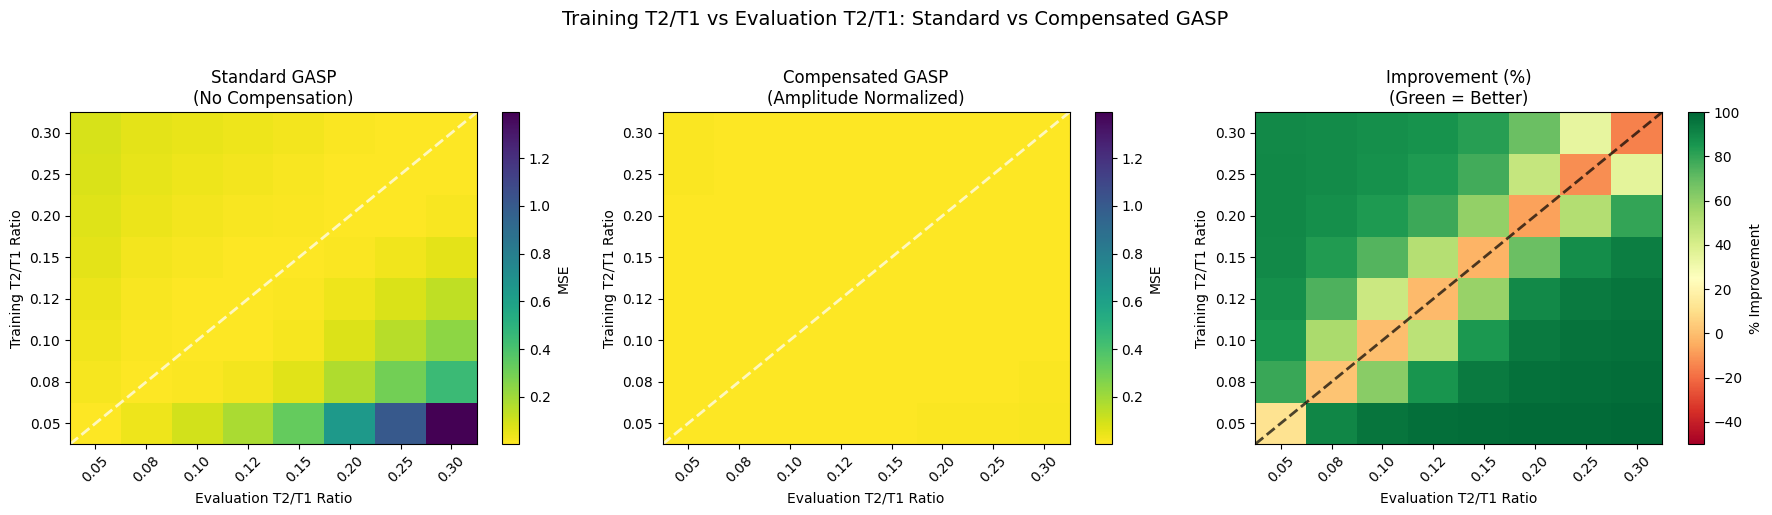


Key Observations:
- Standard GASP: Best performance on diagonal (train=eval tissue)
- Compensated GASP: Uniform performance across all combinations
- White dashed line shows train=eval diagonal


In [39]:
# Plot heatmaps: Standard vs Compensated GASP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Unified color scale
vmin = min(mse_standard.min(), mse_compensated.min())
vmax = max(mse_standard.max(), mse_compensated.max())

# Standard GASP heatmap
im0 = axes[0].imshow(mse_standard, cmap='viridis_r', aspect='auto',
                      vmin=vmin, vmax=vmax, origin='lower')
axes[0].set_xticks(range(n_ratios))
axes[0].set_xticklabels([f'{r:.2f}' for r in T2_T1_RATIOS], rotation=45)
axes[0].set_yticks(range(n_ratios))
axes[0].set_yticklabels([f'{r:.2f}' for r in T2_T1_RATIOS])
axes[0].set_xlabel('Evaluation T2/T1 Ratio')
axes[0].set_ylabel('Training T2/T1 Ratio')
axes[0].set_title('Standard GASP\n(No Compensation)')
plt.colorbar(im0, ax=axes[0], label='MSE')

# Add diagonal line (train = eval)
axes[0].plot([-0.5, n_ratios-0.5], [-0.5, n_ratios-0.5], 'w--', linewidth=2, alpha=0.7)

# Compensated GASP heatmap
im1 = axes[1].imshow(mse_compensated, cmap='viridis_r', aspect='auto',
                      vmin=vmin, vmax=vmax, origin='lower')
axes[1].set_xticks(range(n_ratios))
axes[1].set_xticklabels([f'{r:.2f}' for r in T2_T1_RATIOS], rotation=45)
axes[1].set_yticks(range(n_ratios))
axes[1].set_yticklabels([f'{r:.2f}' for r in T2_T1_RATIOS])
axes[1].set_xlabel('Evaluation T2/T1 Ratio')
axes[1].set_ylabel('Training T2/T1 Ratio')
axes[1].set_title('Compensated GASP\n(Amplitude Normalized)')
plt.colorbar(im1, ax=axes[1], label='MSE')
axes[1].plot([-0.5, n_ratios-0.5], [-0.5, n_ratios-0.5], 'w--', linewidth=2, alpha=0.7)

# Improvement heatmap (ratio)
improvement = (mse_standard - mse_compensated) / mse_standard * 100
im2 = axes[2].imshow(improvement, cmap='RdYlGn', aspect='auto',
                      vmin=-50, vmax=100, origin='lower')
axes[2].set_xticks(range(n_ratios))
axes[2].set_xticklabels([f'{r:.2f}' for r in T2_T1_RATIOS], rotation=45)
axes[2].set_yticks(range(n_ratios))
axes[2].set_yticklabels([f'{r:.2f}' for r in T2_T1_RATIOS])
axes[2].set_xlabel('Evaluation T2/T1 Ratio')
axes[2].set_ylabel('Training T2/T1 Ratio')
axes[2].set_title('Improvement (%)\n(Green = Better)')
plt.colorbar(im2, ax=axes[2], label='% Improvement')
axes[2].plot([-0.5, n_ratios-0.5], [-0.5, n_ratios-0.5], 'k--', linewidth=2, alpha=0.7)

plt.suptitle('Training T2/T1 vs Evaluation T2/T1: Standard vs Compensated GASP', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print observation
print("\nKey Observations:")
print("- Standard GASP: Best performance on diagonal (train=eval tissue)")
print("- Compensated GASP: Uniform performance across all combinations")
print("- White dashed line shows train=eval diagonal")

## Best/Worst Examples & Residual Distribution

Computing residuals across all parameter combinations...
Collected 64 residual profiles


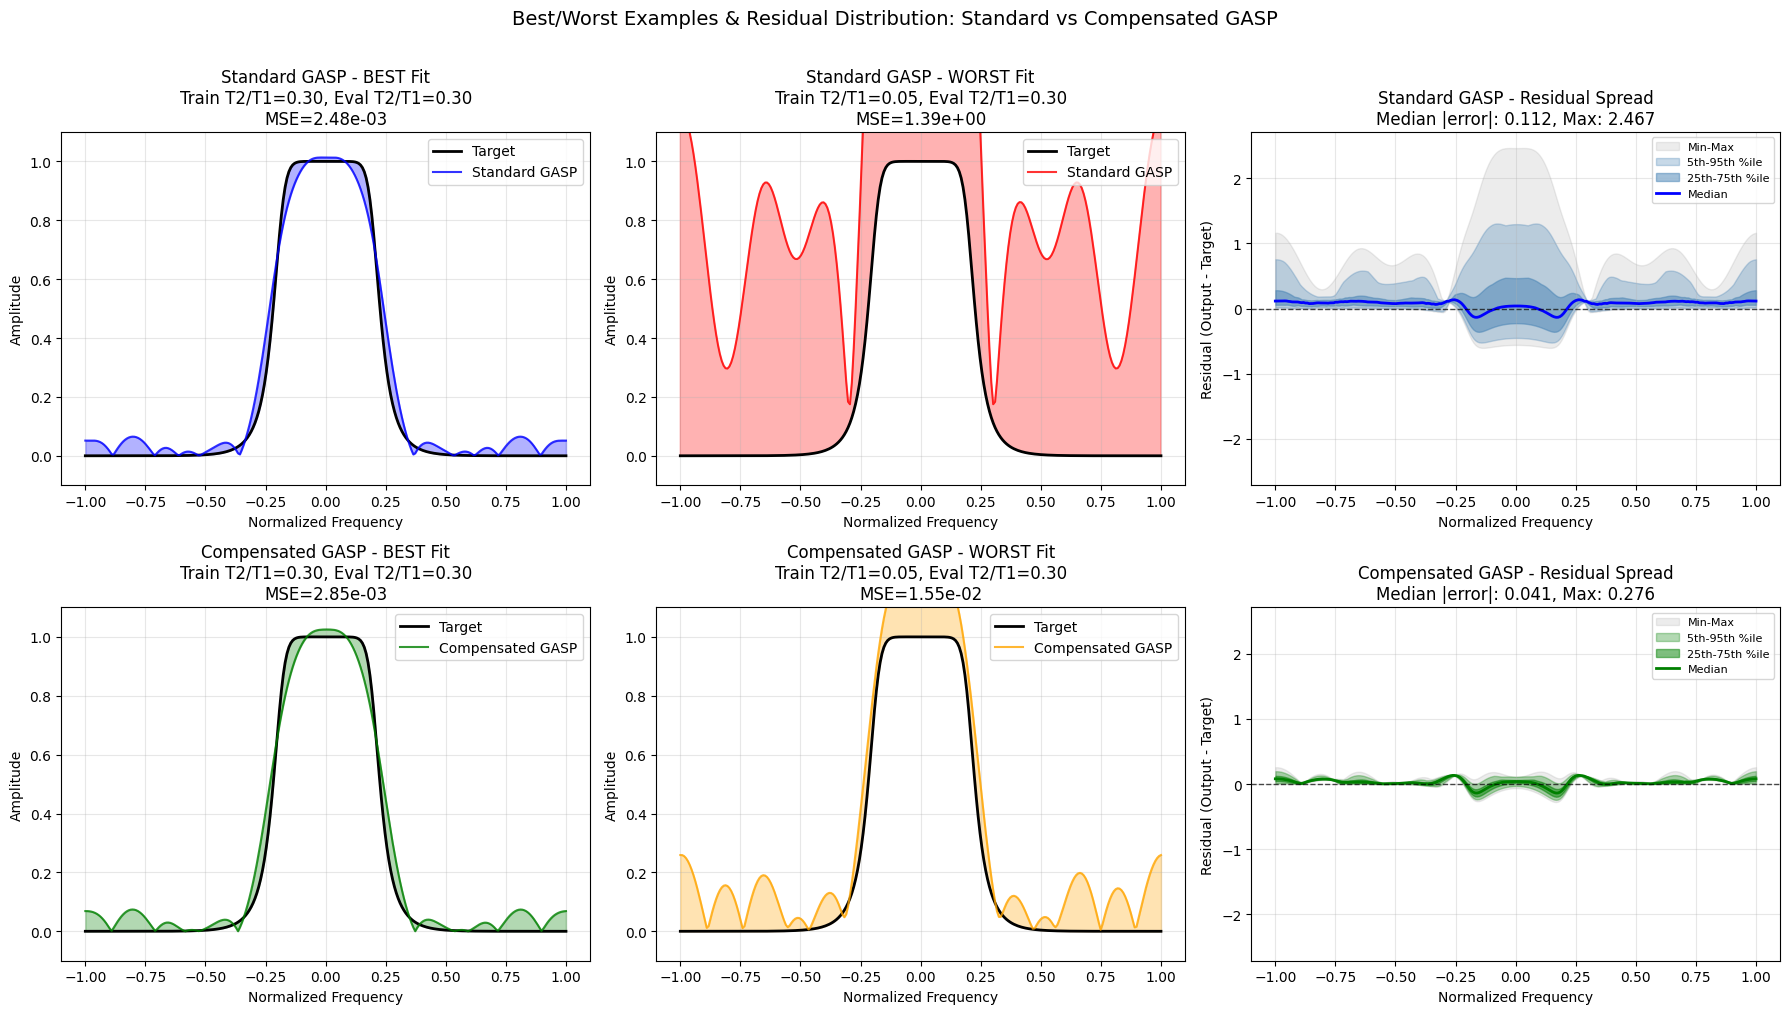

In [40]:
# Best/Worst Examples & Residual Distribution

# Find best and worst cases for standard GASP
best_std_idx = np.unravel_index(np.argmin(mse_standard), mse_standard.shape)
worst_std_idx = np.unravel_index(np.argmax(mse_standard), mse_standard.shape)

# For compensated GASP (should be uniformly good)
best_comp_idx = np.unravel_index(np.argmin(mse_compensated), mse_compensated.shape)
worst_comp_idx = np.unravel_index(np.argmax(mse_compensated), mse_compensated.shape)

# Collect all residuals for both methods
print("Computing residuals across all parameter combinations...")
all_residuals_std = []
all_residuals_comp = []

for i, train_ratio in enumerate(T2_T1_RATIOS):
    train_T1 = T1_BASE
    train_T2 = train_ratio * T1_BASE
    I_train = simulate_tissue(T1=train_T1, T2=train_T2)
    
    _, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
    _, coeffs_comp, meta = train_compensated_gasp(
        I_train, D, TRs, alpha, npcs, method='affine',
        known_t1=train_T1, known_t2=train_T2, useL2=True, lam=1e-2
    )
    
    for j, eval_ratio in enumerate(T2_T1_RATIOS):
        eval_T1 = T1_BASE
        eval_T2 = eval_ratio * T1_BASE
        I_test = simulate_tissue(T1=eval_T1, T2=eval_T2)
        
        out_std = np.abs(run_gasp(I_test, coeffs_std, method='affine')).flatten()
        out_comp = np.abs(run_compensated_gasp(
            I_test, coeffs_comp, meta, method='affine',
            known_t1=eval_T1, known_t2=eval_T2
        )).flatten()
        
        all_residuals_std.append(out_std - D)
        all_residuals_comp.append(out_comp - D)

all_residuals_std = np.array(all_residuals_std)
all_residuals_comp = np.array(all_residuals_comp)
print(f"Collected {len(all_residuals_std)} residual profiles")

# Get specific examples for plotting
def get_output(train_ratio, eval_ratio, compensated=False):
    train_T1 = T1_BASE
    train_T2 = train_ratio * T1_BASE
    eval_T1 = T1_BASE
    eval_T2 = eval_ratio * T1_BASE
    
    I_train = simulate_tissue(T1=train_T1, T2=train_T2)
    I_test = simulate_tissue(T1=eval_T1, T2=eval_T2)
    
    if compensated:
        _, coeffs, meta = train_compensated_gasp(
            I_train, D, TRs, alpha, npcs, method='affine',
            known_t1=train_T1, known_t2=train_T2, useL2=True, lam=1e-2
        )
        out = run_compensated_gasp(I_test, coeffs, meta, method='affine',
                                    known_t1=eval_T1, known_t2=eval_T2)
    else:
        _, coeffs = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
        out = run_gasp(I_test, coeffs, method='affine')
    
    return np.abs(out).flatten()

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
freq_axis = np.linspace(-1, 1, WIDTH)

# Row 1: Standard GASP
# Best case
best_train_r = T2_T1_RATIOS[best_std_idx[0]]
best_eval_r = T2_T1_RATIOS[best_std_idx[1]]
best_out_std = get_output(best_train_r, best_eval_r, compensated=False)
best_mse_std = mse_standard[best_std_idx]

axes[0, 0].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[0, 0].plot(freq_axis, best_out_std, 'b-', linewidth=1.5, label='Standard GASP', alpha=0.8)
axes[0, 0].fill_between(freq_axis, D, best_out_std, alpha=0.3, color='blue')
axes[0, 0].set_title(f'Standard GASP - BEST Fit\nTrain T2/T1={best_train_r:.2f}, Eval T2/T1={best_eval_r:.2f}\nMSE={best_mse_std:.2e}')
axes[0, 0].set_xlabel('Normalized Frequency')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([-0.1, 1.1])

# Worst case
worst_train_r = T2_T1_RATIOS[worst_std_idx[0]]
worst_eval_r = T2_T1_RATIOS[worst_std_idx[1]]
worst_out_std = get_output(worst_train_r, worst_eval_r, compensated=False)
worst_mse_std = mse_standard[worst_std_idx]

axes[0, 1].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[0, 1].plot(freq_axis, worst_out_std, 'r-', linewidth=1.5, label='Standard GASP', alpha=0.8)
axes[0, 1].fill_between(freq_axis, D, worst_out_std, alpha=0.3, color='red')
axes[0, 1].set_title(f'Standard GASP - WORST Fit\nTrain T2/T1={worst_train_r:.2f}, Eval T2/T1={worst_eval_r:.2f}\nMSE={worst_mse_std:.2e}')
axes[0, 1].set_xlabel('Normalized Frequency')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([-0.1, 1.1])

# Residual distribution - Standard GASP
res_median = np.median(all_residuals_std, axis=0)
res_p5 = np.percentile(all_residuals_std, 5, axis=0)
res_p25 = np.percentile(all_residuals_std, 25, axis=0)
res_p75 = np.percentile(all_residuals_std, 75, axis=0)
res_p95 = np.percentile(all_residuals_std, 95, axis=0)
res_min = np.min(all_residuals_std, axis=0)
res_max = np.max(all_residuals_std, axis=0)

axes[0, 2].fill_between(freq_axis, res_min, res_max, alpha=0.15, color='gray', label='Min-Max')
axes[0, 2].fill_between(freq_axis, res_p5, res_p95, alpha=0.3, color='steelblue', label='5th-95th %ile')
axes[0, 2].fill_between(freq_axis, res_p25, res_p75, alpha=0.5, color='steelblue', label='25th-75th %ile')
axes[0, 2].plot(freq_axis, res_median, 'b-', linewidth=2, label='Median')
axes[0, 2].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.7)
max_res = max(abs(res_min).max(), abs(res_max).max())
axes[0, 2].set_ylim([-max_res*1.1, max_res*1.1])
axes[0, 2].set_title(f'Standard GASP - Residual Spread\nMedian |error|: {np.median(np.abs(all_residuals_std)):.3f}, Max: {np.abs(all_residuals_std).max():.3f}')
axes[0, 2].set_xlabel('Normalized Frequency')
axes[0, 2].set_ylabel('Residual (Output - Target)')
axes[0, 2].legend(loc='upper right', fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Compensated GASP
# Best case
best_train_r = T2_T1_RATIOS[best_comp_idx[0]]
best_eval_r = T2_T1_RATIOS[best_comp_idx[1]]
best_out_comp = get_output(best_train_r, best_eval_r, compensated=True)
best_mse_comp = mse_compensated[best_comp_idx]

axes[1, 0].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[1, 0].plot(freq_axis, best_out_comp, 'g-', linewidth=1.5, label='Compensated GASP', alpha=0.8)
axes[1, 0].fill_between(freq_axis, D, best_out_comp, alpha=0.3, color='green')
axes[1, 0].set_title(f'Compensated GASP - BEST Fit\nTrain T2/T1={best_train_r:.2f}, Eval T2/T1={best_eval_r:.2f}\nMSE={best_mse_comp:.2e}')
axes[1, 0].set_xlabel('Normalized Frequency')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([-0.1, 1.1])

# Worst case
worst_train_r = T2_T1_RATIOS[worst_comp_idx[0]]
worst_eval_r = T2_T1_RATIOS[worst_comp_idx[1]]
worst_out_comp = get_output(worst_train_r, worst_eval_r, compensated=True)
worst_mse_comp = mse_compensated[worst_comp_idx]

axes[1, 1].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[1, 1].plot(freq_axis, worst_out_comp, 'orange', linewidth=1.5, label='Compensated GASP', alpha=0.8)
axes[1, 1].fill_between(freq_axis, D, worst_out_comp, alpha=0.3, color='orange')
axes[1, 1].set_title(f'Compensated GASP - WORST Fit\nTrain T2/T1={worst_train_r:.2f}, Eval T2/T1={worst_eval_r:.2f}\nMSE={worst_mse_comp:.2e}')
axes[1, 1].set_xlabel('Normalized Frequency')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([-0.1, 1.1])

# Residual distribution - Compensated GASP
res_median = np.median(all_residuals_comp, axis=0)
res_p5 = np.percentile(all_residuals_comp, 5, axis=0)
res_p25 = np.percentile(all_residuals_comp, 25, axis=0)
res_p75 = np.percentile(all_residuals_comp, 75, axis=0)
res_p95 = np.percentile(all_residuals_comp, 95, axis=0)
res_min = np.min(all_residuals_comp, axis=0)
res_max = np.max(all_residuals_comp, axis=0)

axes[1, 2].fill_between(freq_axis, res_min, res_max, alpha=0.15, color='gray', label='Min-Max')
axes[1, 2].fill_between(freq_axis, res_p5, res_p95, alpha=0.3, color='green', label='5th-95th %ile')
axes[1, 2].fill_between(freq_axis, res_p25, res_p75, alpha=0.5, color='green', label='25th-75th %ile')
axes[1, 2].plot(freq_axis, res_median, 'g-', linewidth=2, label='Median')
axes[1, 2].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.7)
# Use same y-axis scale as standard for fair comparison
axes[1, 2].set_ylim([-max_res*1.1, max_res*1.1])
axes[1, 2].set_title(f'Compensated GASP - Residual Spread\nMedian |error|: {np.median(np.abs(all_residuals_comp)):.3f}, Max: {np.abs(all_residuals_comp).max():.3f}')
axes[1, 2].set_xlabel('Normalized Frequency')
axes[1, 2].set_ylabel('Residual (Output - Target)')
axes[1, 2].legend(loc='upper right', fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Best/Worst Examples & Residual Distribution: Standard vs Compensated GASP', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Residual Statistics Table

In [41]:
# Residual Statistics Table

# Compute statistics for both methods
abs_residuals_std = np.abs(all_residuals_std)
abs_residuals_comp = np.abs(all_residuals_comp)

stats = {
    'Standard GASP': {
        'min': abs_residuals_std.min(),
        'max': abs_residuals_std.max(),
        'mean': abs_residuals_std.mean(),
        'median': np.median(abs_residuals_std),
        'p5': np.percentile(abs_residuals_std, 5),
        'p25': np.percentile(abs_residuals_std, 25),
        'p75': np.percentile(abs_residuals_std, 75),
        'p95': np.percentile(abs_residuals_std, 95),
    },
    'Compensated GASP': {
        'min': abs_residuals_comp.min(),
        'max': abs_residuals_comp.max(),
        'mean': abs_residuals_comp.mean(),
        'median': np.median(abs_residuals_comp),
        'p5': np.percentile(abs_residuals_comp, 5),
        'p25': np.percentile(abs_residuals_comp, 25),
        'p75': np.percentile(abs_residuals_comp, 75),
        'p95': np.percentile(abs_residuals_comp, 95),
    }
}

# Print formatted table
print("=" * 100)
print("RESIDUAL STATISTICS (Absolute Values Across All Train/Eval T2/T1 Combinations)")
print("=" * 100)
print(f"{'Method':<20} {'Min':<10} {'Max':<10} {'Mean':<10} {'Median':<10} {'5th %':<10} {'25th %':<10} {'75th %':<10} {'95th %':<10}")
print("-" * 100)

for method, s in stats.items():
    print(f"{method:<20} {s['min']:<10.4f} {s['max']:<10.4f} {s['mean']:<10.4f} {s['median']:<10.4f} "
          f"{s['p5']:<10.4f} {s['p25']:<10.4f} {s['p75']:<10.4f} {s['p95']:<10.4f}")

print("=" * 100)
print(f"\nNote: Statistics computed from {n_ratios**2} combinations ({n_ratios} train × {n_ratios} eval T2/T1 ratios)")
print(f"      Each combination evaluated across {WIDTH} frequency points")

# Improvement summary
print("\n" + "=" * 100)
print("IMPROVEMENT SUMMARY")
print("=" * 100)
print(f"{'Metric':<25} {'Standard':<15} {'Compensated':<15} {'Improvement':<15}")
print("-" * 100)

for metric in ['mean', 'median', 'max', 'p95']:
    std_val = stats['Standard GASP'][metric]
    comp_val = stats['Compensated GASP'][metric]
    improvement = (1 - comp_val / std_val) * 100
    print(f"{metric.capitalize() + ' |error|':<25} {std_val:<15.4f} {comp_val:<15.4f} {improvement:>+10.1f}%")

print("=" * 100)

# MSE summary
print("\n" + "=" * 100)
print("MSE SUMMARY")  
print("=" * 100)
print(f"{'Metric':<25} {'Standard':<15} {'Compensated':<15} {'Improvement':<15}")
print("-" * 100)
print(f"{'Mean MSE':<25} {mse_standard.mean():<15.6f} {mse_compensated.mean():<15.6f} {(1 - mse_compensated.mean()/mse_standard.mean())*100:>+10.1f}%")
print(f"{'Min MSE':<25} {mse_standard.min():<15.6f} {mse_compensated.min():<15.6f} {(1 - mse_compensated.min()/mse_standard.min())*100:>+10.1f}%")
print(f"{'Max MSE':<25} {mse_standard.max():<15.6f} {mse_compensated.max():<15.6f} {(1 - mse_compensated.max()/mse_standard.max())*100:>+10.1f}%")
print(f"{'Std MSE':<25} {mse_standard.std():<15.6f} {mse_compensated.std():<15.6f} {(1 - mse_compensated.std()/mse_standard.std())*100:>+10.1f}%")
print("=" * 100)
print("\nAmplitude compensation significantly reduces MSE variance across tissue types!")

RESIDUAL STATISTICS (Absolute Values Across All Train/Eval T2/T1 Combinations)
Method               Min        Max        Mean       Median     5th %      25th %     75th %     95th %    
----------------------------------------------------------------------------------------------------
Standard GASP        0.0000     2.4666     0.1911     0.1123     0.0103     0.0524     0.2204     0.6302    
Compensated GASP     0.0000     0.2765     0.0533     0.0408     0.0029     0.0151     0.0771     0.1401    

Note: Statistics computed from 64 combinations (8 train × 8 eval T2/T1 ratios)
      Each combination evaluated across 256 frequency points

IMPROVEMENT SUMMARY
Metric                    Standard        Compensated     Improvement    
----------------------------------------------------------------------------------------------------
Mean |error|              0.1911          0.0533               +72.1%
Median |error|            0.1123          0.0408               +63.7%
Max |error|     